# Deep Learning for Conspiracy Detection
## Binary classification: conspiracy labels (yes/no) using Transformer Models

This notebook implements a deep learning approach using transformer models for:
1. **Conspiracy Label Prediction**: **binary** yes/no (samples with label *cant_tell* are excluded from training, validation, and testing)
2. **Model**: RoBERTa-large text classifier (using only text, no engineered features) - training top layers
3. **Model Evaluation**: 90% train / 10% validation split on full training data; no held-out validation set.
4. **Final Evaluation**: Dev set only — text from dev_rehydrated.jsonl, labels from dev_public.jsonl (merge on _id, yes/no only).

**Note**: Unlike other notebooks that use engineered features, this approach uses only the raw text and learns representations directly from the text data.

## Environment Setup

This notebook requires **NumPy 2.x** and compatible packages. The virtual environment should be set up using the `recreate_venv.sh` script which installs all packages with NumPy 2.x compatibility.


In [1]:
# Verify environment setup and package versions
# Suppress tokenizers parallelism warning
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Import and verify all packages
import numpy as np
import pandas as pd
import torch
from transformers import __version__ as transformers_version

print("=" * 60)
print("Environment Verification")
print("=" * 60)

# Check NumPy
print(f"✓ NumPy version: {np.__version__}")
if not np.__version__.startswith('2.'):
    print("⚠ WARNING: NumPy 2.x is required but version", np.__version__, "is installed")

# Check PyTorch
print(f"✓ PyTorch version: {torch.__version__}")
try:
    test_tensor = torch.tensor([1, 2, 3])
    test_numpy = test_tensor.numpy()
    print("✓ PyTorch-NumPy compatibility: OK")
except Exception as e:
    print(f"❌ PyTorch-NumPy compatibility issue: {e}")
    print("   This may indicate PyTorch was not compiled with NumPy 2.x support")
    print("   Please run: bash EDA-Rehydrated/recreate_venv.sh")

# Check Transformers
print(f"✓ Transformers version: {transformers_version}")

# Check for GPU support (CUDA or ROCm)
is_rocm = hasattr(torch.version, 'hip') and torch.version.hip is not None
is_cuda_available = torch.cuda.is_available()

if is_rocm:
    print(f"✓ ROCm available: True")
    print(f"✓ ROCm version: {torch.version.hip}")
    print(f"✓ Device count: {torch.cuda.device_count()}")
    if torch.cuda.device_count() > 0:
        print(f"✓ Primary device: {torch.cuda.get_device_name(0)}")
        print(f"ℹ Training will use ROCm GPU(s)")
elif is_cuda_available:
    print(f"✓ CUDA available: True")
    print(f"✓ CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"✓ CUDA version: {torch.version.cuda}")
    print(f"ℹ Training will use CUDA GPU(s)")
else:
    print("✓ CUDA/ROCm available: False")
    print("ℹ Training will use CPU")

print("=" * 60)
print("✓ Environment check complete")
print("=" * 60)

/home/husnain/semeval26_psycholinguistic_markers/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment Verification
✓ NumPy version: 2.2.6
✓ PyTorch version: 2.9.1+rocm6.4
✓ PyTorch-NumPy compatibility: OK
✓ Transformers version: 4.57.3
✓ ROCm available: True
✓ ROCm version: 6.4.43484-123eb5128
✓ Device count: 8
✓ Primary device: AMD Instinct MI250X/MI250
ℹ Training will use ROCm GPU(s)
✓ Environment check complete


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Ensure numpy is properly available for transformers
# This is a workaround for numpy 2.x compatibility issues
import sys
if 'numpy' not in sys.modules:
    import numpy
    sys.modules['numpy'] = numpy

# Deep learning libraries
import torch
from transformers import (
    RobertaTokenizerFast, 
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Libraries imported successfully!")
print("=" * 50)
print("Environment Information:")
print("=" * 50)
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ NumPy version: {np.__version__}")

# Check for GPU support (CUDA or ROCm)
is_rocm = hasattr(torch.version, 'hip') and torch.version.hip is not None
is_cuda_available = torch.cuda.is_available()

if is_rocm:
    print(f"✓ ROCm available: True")
    print(f"✓ ROCm version: {torch.version.hip}")
    print(f"✓ Device count: {torch.cuda.device_count()}")
    if torch.cuda.device_count() > 0:
        print(f"✓ Primary device: {torch.cuda.get_device_name(0)}")
        print(f"ℹ Training will use ROCm GPU(s)")
elif is_cuda_available:
    print(f"✓ CUDA available: True")
    print(f"✓ CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"✓ CUDA version: {torch.version.cuda}")
    print(f"ℹ Training will use CUDA GPU(s)")
else:
    print("✓ CUDA/ROCm available: False")
    print("⚠ Training will use CPU (slower than GPU)")
print("=" * 50)


Libraries imported successfully!
Environment Information:
✓ PyTorch version: 2.9.1+rocm6.4
✓ NumPy version: 2.2.6
✓ ROCm available: True
✓ ROCm version: 6.4.43484-123eb5128
✓ Device count: 8
✓ Primary device: AMD Instinct MI250X/MI250
ℹ Training will use ROCm GPU(s)


## Load Data

We only need the `text` and `conspiracy` columns for deep learning. The transformer model will learn features directly from the text.


In [3]:
# Load base data - we only need text and labels
BASE = Path('../')
PROC = BASE / 'data_processed'

# Load base data from data_clean.csv (contains _id, text, conspiracy)
df = pd.read_csv(PROC / 'data_clean.csv')

print(f"Loaded {len(df)} documents")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution (original):")
print(df['conspiracy'].value_counts())

# Remove any rows with missing text or labels
df = df.dropna(subset=['text', 'conspiracy'])

# Binary classification: keep only yes and no; exclude cant_tell from training, validation, and testing
df = df[df['conspiracy'].isin(['yes', 'no'])].copy()
print(f"\nAfter keeping only yes/no (binary): {len(df)} documents")
print(f"\nLabel distribution (binary):")
print(df['conspiracy'].value_counts())

# Keep only text and conspiracy for display (df keeps _id for train/test split)
df_model = df[['text', 'conspiracy']].copy()

# Display sample texts
print("\n=== Sample Texts ===")
for label in ['yes', 'no']:
    sample = df_model[df_model['conspiracy'] == label].iloc[0]
    print(f"\nLabel: {label}")
    print(f"Text (first 200 chars): {sample['text'][:200]}...")


Loaded 3011 documents

Columns: ['_id', 'text', 'conspiracy']

Label distribution (original):
conspiracy
no     1708
yes    1303
Name: count, dtype: int64

After keeping only yes/no (binary): 3011 documents

Label distribution (binary):
conspiracy
no     1708
yes    1303
Name: count, dtype: int64

=== Sample Texts ===

Label: yes
Text (first 200 chars): A great article on what's taking place in Bolivia, referencing some similar US backed coups in the region as well as recounting some of Bolivia's history and western policy towards the country....

Label: no
Text (first 200 chars): Germany has upset other EU member states by securing a disproportionately large share of the bloc’s common pool of vaccines, according to a report. 
 Brussels  has ordered  roughly two billion doses i...


## Create Train/Validation Split (90% train / 10% validation)

Use **all** training data (yes/no only) for model training. A 90/10 stratified split is used for train/validation during training. **Final evaluation** is on the dev set (dev_rehydrated + dev_public), not a held-out validation set.


In [4]:
# Use all training data. 90/10 train/validation split is done later for training.
# Final evaluation is on dev set (dev_rehydrated + dev_public), not a held-out set.
df_with_id = df[['_id', 'text', 'conspiracy']].dropna(subset=['text', 'conspiracy'])
train_df = df_with_id[['text', 'conspiracy']].copy()

print("Training set: all data (90% train / 10% validation split for training loop)")
print(f"  Total: {len(train_df)} samples")
print(f"  Class distribution: {train_df['conspiracy'].value_counts().to_dict()}")
print("\nFinal evaluation will be on dev set (dev_rehydrated.jsonl + dev_public.jsonl).")


Training set: all data (90% train / 10% validation split for training loop)
  Total: 3011 samples
  Class distribution: {'no': 1708, 'yes': 1303}

Final evaluation will be on dev set (dev_rehydrated.jsonl + dev_public.jsonl).


## Data Augmentation

Apply augmentation techniques to expand the dataset and improve model robustness:
- **Backtranslation**: Translate to another language and back to English
- **BERT Synonym Replacement**: Replace words with BERT-predicted synonyms
- **Dataset Expansion**: Create 1 augmented version per original sample (results in ~2x total dataset)


In [5]:
# Data Augmentation for Dataset Expansion
print("=" * 60)
print("Data Augmentation")
print("=" * 60)

# Check if augmented dataset already exists
augmented_file = PROC / 'data_augmented.csv'
if augmented_file.exists():
    print(f"\n✓ Augmented dataset already exists at: {augmented_file}")
    print(f"  Loading existing augmented dataset...")
    
    # Load the existing augmented dataset
    train_df = pd.read_csv(augmented_file)
    # Binary classification: keep only yes/no
    train_df = train_df[train_df['conspiracy'].isin(['yes', 'no'])].copy()
    
    print(f"\n✓ Loaded augmented dataset from CSV (binary: yes/no only)")
    print(f"  Total samples: {len(train_df)}")
    dist = train_df['conspiracy'].value_counts().to_dict()
    print(f"  Class distribution: {dist}")
    print(f"\n✓ Skipping augmentation - using existing dataset")
    print("=" * 60)
    
else:
    # Augmentation needed - proceed with augmentation process
    print(f"\n⚠ Augmented dataset not found. Proceeding with augmentation...")
    print(f"  Expected location: {augmented_file}")
    
    # Check if train_df exists (should be created in the train/test split cell)
    if 'train_df' not in globals():
        raise NameError(
            "train_df is not defined. Please run the 'Create Train/Test Split' cell (Cell 6) first.\n"
            "The augmentation should be applied to the training set after it's been split from the test set.\n"
            "The correct order is:\n"
            "  1. Load Data (Cell 4)\n"
            "  2. Create Train/Test Split (Cell 6)\n"
            "  3. Data Augmentation (this cell - Cell 8)"
        )

    # Check class distribution before augmentation
    print("\nOriginal training set class distribution:")
    original_dist = train_df['conspiracy'].value_counts()
    print(original_dist.to_dict())

    # Install required packages if not available
    print("\nInstalling/checking augmentation libraries...")
    try:
        import nlpaug.augmenter.word as naw
        import nlpaug.augmenter.sentence as nas
        print("✓ nlpaug already installed")
    except ImportError:
        print("Installing nlpaug...")
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "nlpaug", "--quiet"])
        import nlpaug.augmenter.word as naw
        import nlpaug.augmenter.sentence as nas

    try:
        import sentencepiece
        print("✓ sentencepiece already installed")
    except ImportError:
        print("Installing sentencepiece...")
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "sentencepiece", "--quiet"])
        import sentencepiece

    try:
        from deep_translator import GoogleTranslator
        print("✓ deep-translator already installed")
    except ImportError:
        print("Installing deep-translator...")
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "deep-translator", "--quiet"])
        from deep_translator import GoogleTranslator

    print("✓ All augmentation libraries loaded")

    # Initialize augmenters
    print("\nInitializing augmenters...")

    # Detect device for BERT augmenter
    import torch
    if torch.cuda.is_available():
        device = 'cuda'  # Works for both CUDA and ROCm
        print(f"  Using device: {device} (GPU detected)")
    else:
        device = 'cpu'
        print(f"  Using device: {device} (CPU)")

    # BERT-based synonym replacement (using RoBERTa for consistency)
    try:
        bert_aug = naw.ContextualWordEmbsAug(
            model_path='roberta-base',
            action="substitute",
            device=device,
            aug_p=0.05  # 10% of words will be replaced
        )
        print("✓ BERT synonym replacement augmenter initialized")
        bert_available = True
    except Exception as e:
        print(f"⚠ BERT augmenter initialization failed: {e}")
        bert_available = False
        bert_aug = None

    # Backtranslation using transformers (more reliable)
    # Make sure sentencepiece is imported before using MarianTokenizer
    try:
        import sentencepiece
    except ImportError:
        print("  Installing sentencepiece for MarianMT...")
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "sentencepiece", "--quiet"])
        import sentencepiece

    try:
        from transformers import MarianMTModel, MarianTokenizer
        
        # Load translation models
        print("  Loading translation models (this may take a moment)...")
        en_de_tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-de')
        en_de_model = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-en-de')
        if torch.cuda.is_available():
            en_de_model = en_de_model.to(device)
        de_en_tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-de-en')
        de_en_model = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-de-en')
        if torch.cuda.is_available():
            de_en_model = de_en_model.to(device)
        
        def backtranslate_with_marian(text):
            """Backtranslate using MarianMT models"""
            try:
                if len(text.strip()) == 0:
                    return text
                # Translate to German
                inputs = en_de_tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
                if torch.cuda.is_available():
                    inputs = {k: v.to(device) for k, v in inputs.items()}
                translated = en_de_model.generate(**inputs)
                german_text = en_de_tokenizer.decode(translated[0], skip_special_tokens=True)
                
                # Translate back to English
                inputs = de_en_tokenizer(german_text, return_tensors="pt", padding=True, truncation=True, max_length=512)
                if torch.cuda.is_available():
                    inputs = {k: v.to(device) for k, v in inputs.items()}
                backtranslated = de_en_model.generate(**inputs)
                english_text = de_en_tokenizer.decode(backtranslated[0], skip_special_tokens=True)
                
                return english_text if english_text and english_text.strip() else text
            except Exception as e:
                return text
        
        print("✓ Backtranslation augmenter initialized (MarianMT)")
        backtranslation_available = True
    except Exception as e:
        print(f"⚠ MarianMT backtranslation initialization failed: {e}")
        print("  Trying deep-translator fallback...")
        try:
            translator_de = GoogleTranslator(source='en', target='de')
            translator_en = GoogleTranslator(source='de', target='en')
            def backtranslate_with_marian(text):
                try:
                    if len(text.strip()) == 0:
                        return text
                    # Translate to German
                    translated = translator_de.translate(text)
                    if not translated or translated == text:
                        return text
                    # Translate back to English
                    backtranslated = translator_en.translate(translated)
                    return backtranslated if backtranslated and backtranslated.strip() else text
                except Exception as e:
                    return text
            backtranslation_available = True
            print("✓ Backtranslation augmenter initialized (deep-translator)")
        except Exception as e2:
            print(f"⚠ deep-translator also failed: {e2}")
            backtranslation_available = False
            def backtranslate_with_marian(text):
                return text

    # Function to augment text with multiple techniques
    def augment_text(text, method='bert'):
        """Augment text using specified method"""
        try:
            if method == 'bert' and bert_available and bert_aug:
                # BERT synonym replacement
                aug_text = bert_aug.augment(text)
                if isinstance(aug_text, list):
                    aug_text = aug_text[0] if aug_text else text
                # Ensure we return a string
                if aug_text and aug_text != text:
                    return str(aug_text)
                return text
            elif method == 'backtranslation' and backtranslation_available:
                # Backtranslation
                aug_text = backtranslate_with_marian(text)
                if aug_text and aug_text != text:
                    return str(aug_text)
                return text
            else:
                return text
        except Exception as e:
            # Silently return original text on error
            return text

    # Test augmenters with a sample text
    print("\nTesting augmenters with sample text...")
    test_text = "This is a test sentence for augmentation."
    print(f"  Original: {test_text}")

    if bert_available and bert_aug:
        try:
            test_bert = augment_text(test_text, method='bert')
            if test_bert != test_text:
                print(f"  BERT augmentation: {test_bert[:100]}...")
            else:
                print(f"  BERT augmentation: No change (may need more samples)")
        except Exception as e:
            print(f"  BERT test failed: {e}")

    if backtranslation_available:
        try:
            test_bt = augment_text(test_text, method='backtranslation')
            if test_bt != test_text:
                print(f"  Backtranslation: {test_bt[:100]}...")
            else:
                print(f"  Backtranslation: No change")
        except Exception as e:
            print(f"  Backtranslation test failed: {e}")

    # Augment data to expand dataset
    print("\n" + "=" * 60)
    print("Augmenting data to expand dataset...")
    print("=" * 60)

    # Configuration: number of augmentations per original sample
    AUGMENTATIONS_PER_SAMPLE = 1  # Create 1 augmented version per original sample (results in 2x total dataset)

    augmented_data = []
    np.random.seed(42)  # For reproducibility

    print(f"\nAugmentation strategy:")
    print(f"  - Creating {AUGMENTATIONS_PER_SAMPLE} augmented version per original sample")
    print(f"  - Expected total dataset size: ~{len(train_df) * (1 + AUGMENTATIONS_PER_SAMPLE)} samples")

    # Augment all samples to expand dataset
    print(f"\n{'='*60}")
    print("Augmenting all samples to expand dataset...")
    print(f"{'='*60}")

    total_augmented = 0
    bert_success = 0
    bt_success = 0
    failed_count = 0

    for idx, row in train_df.iterrows():
        text = row['text']
        label = row['conspiracy']
        
        # Create augmented version
        for aug_idx in range(AUGMENTATIONS_PER_SAMPLE):
            # Alternate between BERT and backtranslation, but prefer available method
            if aug_idx % 2 == 0:
                method = 'bert' if bert_available else 'backtranslation'
            else:
                method = 'backtranslation' if backtranslation_available else 'bert'
            
            # Skip if method is not available
            if (method == 'bert' and not bert_available) or (method == 'backtranslation' and not backtranslation_available):
                failed_count += 1
                continue
            
            aug_text = augment_text(text, method=method)
            
            # Only add if augmentation produced different text
            if aug_text != text and len(aug_text.strip()) > 0:
                augmented_data.append({
                    'text': aug_text,
                    'conspiracy': label
                })
                total_augmented += 1
                if method == 'bert':
                    bert_success += 1
                else:
                    bt_success += 1
            else:
                failed_count += 1
        
        if (idx + 1) % 500 == 0:
            print(f"  Processed {idx + 1}/{len(train_df)} samples, generated {total_augmented} augmentations (BERT: {bert_success}, BT: {bt_success}, failed: {failed_count})...")

    print(f"\n✓ Generated {total_augmented} augmented samples from all original samples")
    print(f"  - BERT augmentations: {bert_success}")
    print(f"  - Backtranslation augmentations: {bt_success}")
    print(f"  - Failed attempts: {failed_count}")

    # Combine original and augmented data
    if augmented_data:
        augmented_df = pd.DataFrame(augmented_data)
        train_df_augmented = pd.concat([train_df, augmented_df], ignore_index=True)
        print(f"\n{'='*60}")
        print(f"Augmentation complete!")
        print(f"{'='*60}")
        print(f"Original training samples: {len(train_df)}")
        print(f"Augmented samples: {len(augmented_df)}")
        print(f"Total training samples: {len(train_df_augmented)}")
        print(f"Dataset expansion: {len(train_df_augmented) / len(train_df):.2f}x")
        
        print(f"\nFinal class distribution:")
        final_dist = train_df_augmented['conspiracy'].value_counts()
        print(final_dist.to_dict())
        
        # Update train_df to use augmented version
        train_df = train_df_augmented.copy()
        print(f"\n✓ Training data updated with augmented samples")
    else:
        print("\n⚠ No augmentation was performed (augmentation failed)")
        print("Continuing with original data...")

    print("=" * 60)


Data Augmentation

✓ Augmented dataset already exists at: ../data_processed/data_augmented.csv
  Loading existing augmented dataset...

✓ Loaded augmented dataset from CSV (binary: yes/no only)
  Total samples: 5858
  Class distribution: {'no': 3324, 'yes': 2534}

✓ Skipping augmentation - using existing dataset


In [6]:
# Save augmented dataset to disk
print("=" * 60)
print("Saving Augmented Dataset")
print("=" * 60)

if 'train_df' in globals() and len(train_df) > 0:
    # Ensure the directory exists
    PROC.mkdir(parents=True, exist_ok=True)
    
    augmented_file = PROC / 'data_augmented.csv'
    train_df.to_csv(augmented_file, index=False)
    
    print(f"✓ Saved augmented dataset to {augmented_file}")
    print(f"  Total samples: {len(train_df)}")
    print(f"  Class distribution:")
    dist = train_df['conspiracy'].value_counts().to_dict()
    print(f"    {dist}")
    print(f"\n✓ Dataset saved successfully!")
    print(f"  File path: {augmented_file.absolute()}")
    print(f"  File size: {augmented_file.stat().st_size / 1024 / 1024:.2f} MB")
else:
    print("⚠ train_df not found or empty. Please run the augmentation cell first.")
    print("  Training will use original data without augmentation.")

print("=" * 60)

Saving Augmented Dataset
✓ Saved augmented dataset to ../data_processed/data_augmented.csv
  Total samples: 5858
  Class distribution:
    {'no': 3324, 'yes': 2534}

✓ Dataset saved successfully!
  File path: /home/husnain/semeval26_psycholinguistic_markers/EDA-Rehydrated/notebooks/../data_processed/data_augmented.csv
  File size: 2.40 MB


## Load Augmented Dataset

Load the augmented dataset from CSV file for training. This allows you to reuse the augmented dataset without re-running augmentation.


In [7]:
# Load augmented dataset from CSV
print("=" * 60)
print("Loading Augmented Dataset")
print("=" * 60)

augmented_file = PROC / 'data_augmented.csv'

if augmented_file.exists():
    print(f"✓ Found augmented dataset at: {augmented_file}")
    print(f"  Loading from CSV...")
    
    # Load the augmented dataset
    train_df_loaded = pd.read_csv(augmented_file)
    # Binary classification: keep only yes/no
    train_df_loaded = train_df_loaded[train_df_loaded['conspiracy'].isin(['yes', 'no'])].copy()
    
    print(f"\n✓ Dataset loaded successfully! (binary: yes/no only)")
    print(f"  Total samples: {len(train_df_loaded)}")
    print(f"  Columns: {list(train_df_loaded.columns)}")
    
    # Check class distribution
    if 'conspiracy' in train_df_loaded.columns:
        dist = train_df_loaded['conspiracy'].value_counts().to_dict()
        print(f"\n  Class distribution:")
        for label, count in dist.items():
            print(f"    {label}: {count}")
        
        # Update train_df to use loaded augmented data
        train_df = train_df_loaded.copy()
        print(f"\n✓ train_df updated with augmented dataset from CSV")
        print(f"  Ready for training with {len(train_df)} samples")
    else:
        print(f"⚠ Warning: 'conspiracy' column not found in CSV")
        print(f"  Available columns: {list(train_df_loaded.columns)}")
        print(f"  Using loaded data as-is...")
        train_df = train_df_loaded.copy()
else:
    print(f"⚠ Augmented dataset not found at: {augmented_file}")
    print(f"  Checking if train_df exists in memory...")
    
    if 'train_df' in globals() and len(train_df) > 0:
        print(f"✓ Using train_df from memory ({len(train_df)} samples)")
        print(f"  Note: Run the 'Save Augmented Dataset' cell to save it for future use")
    else:
        print(f"❌ No augmented dataset found and train_df not available")
        print(f"  Please run the augmentation cell first, or load the original data")

print("=" * 60)


Loading Augmented Dataset
✓ Found augmented dataset at: ../data_processed/data_augmented.csv
  Loading from CSV...

✓ Dataset loaded successfully! (binary: yes/no only)
  Total samples: 5858
  Columns: ['text', 'conspiracy']

  Class distribution:
    no: 3324
    yes: 2534

✓ train_df updated with augmented dataset from CSV
  Ready for training with 5858 samples


## Prepare Data for Training

Set up a train/validation split on the training set. The test set will be used only for final evaluation.


In [8]:
# Model configuration
MODEL_NAME = "roberta-large"  # RoBERTa large model
MAX_LENGTH = 512  # Reduced to prevent GPU overload
# Use a single train/validation split instead of k-fold CV
# This allows using more data for training
VALIDATION_SPLIT = 0.1  # 10% for validation, 90% for training

# Encode labels (fit on training set only)
label_encoder = LabelEncoder()
label_encoder.fit(train_df['conspiracy'])

# Create label mappings
label_to_id = {label: int(id) for label, id in zip(label_encoder.classes_, range(len(label_encoder.classes_)))}
id_to_label = {int(id): label for label, id in label_to_id.items()}

print(f"Label mappings:")
print(f"  Label to ID: {label_to_id}")
print(f"  ID to Label: {id_to_label}")
print(f"  Number of classes: {len(label_to_id)}")

# Prepare training data for k-fold CV
train_texts = train_df['text'].tolist()
train_labels = label_encoder.transform(train_df['conspiracy']).tolist()

print(f"\nTraining set: {len(train_texts)} samples (will be split 90% train / 10% validation)")
print("Final evaluation will be on dev set (dev_rehydrated + dev_public).")

# Load tokenizer
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)

# Tokenize function - NO PADDING (will be done dynamically per batch)
# Set max_length for truncation only to prevent extremely long sequences
# Dynamic padding will be applied per batch by DataCollatorWithPadding
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_LENGTH,  # Truncate only if longer than MAX_LENGTH
        # padding is NOT done here - will be done dynamically per batch
    )

print("\n✓ Data preparation complete!")
print("✓ Dynamic padding enabled - sequences will be padded per batch to preserve context")
print(f"✓ Maximum sequence length: {MAX_LENGTH} (truncation only if longer)")


Label mappings:
  Label to ID: {'no': 0, 'yes': 1}
  ID to Label: {0: 'no', 1: 'yes'}
  Number of classes: 2

Training set: 5858 samples (will be split 90% train / 10% validation)
Final evaluation will be on dev set (dev_rehydrated + dev_public).

✓ Data preparation complete!
✓ Dynamic padding enabled - sequences will be padded per batch to preserve context
✓ Maximum sequence length: 512 (truncation only if longer)


## Train/Validation Split Setup

Set up a stratified train/validation split on the training set.


In [9]:
# Set up train/validation split
from sklearn.model_selection import train_test_split

# Create stratified train/validation split
train_indices, val_indices = train_test_split(
    range(len(train_texts)),
    test_size=VALIDATION_SPLIT,
    stratify=train_labels,
    random_state=42
)

print(f"Train/Validation Split Setup")
print("=" * 60)
print(f"Training samples: {len(train_indices)} ({100*(1-VALIDATION_SPLIT):.1f}%)")
print(f"Validation samples: {len(val_indices)} ({100*VALIDATION_SPLIT:.1f}%)")

# Show class distribution in validation set
val_labels_split = [train_labels[i] for i in val_indices]
val_label_counts = pd.Series(val_labels_split).value_counts().sort_index()
print(f"\nValidation set class distribution:")
print(dict(zip([id_to_label[i] for i in val_label_counts.index], val_label_counts.values)))

# Show class distribution in training set
train_labels_split = [train_labels[i] for i in train_indices]
train_label_counts = pd.Series(train_labels_split).value_counts().sort_index()
print(f"\nTraining set class distribution:")
print(dict(zip([id_to_label[i] for i in train_label_counts.index], train_label_counts.values)))
print("=" * 60)

# Training hyperparameters
# Reduced batch size to prevent OOM errors
BATCH_SIZE = 2  # Further reduced to prevent GPU overload
GRADIENT_ACCUMULATION_STEPS = 16  # Increased to maintain effective batch size of 16
LEARNING_RATE = 5e-5  # 
NUM_EPOCHS = 20
WEIGHT_DECAY = 0 #.01
WARMUP_RATIO = 0 #.01  # 10% warmup
DROPOUT_RATE = 0 #0.01  # Increased dropout (default is usually 0.1)
NUM_TOP_LAYERS_TO_TRAIN = 12  # Train top 12 layers (RoBERTa-large has 24 layers total)
num_labels = len(label_to_id)

print(f"\nTraining Configuration:")
print(f"  Model: {MODEL_NAME}")
print(f"  Number of classes: {num_labels}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Gradient accumulation steps: {GRADIENT_ACCUMULATION_STEPS}")
print(f"  Effective batch size: {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Warmup ratio: {WARMUP_RATIO*100:.0f}%")
print(f"  Dropout rate: {DROPOUT_RATE}")
print(f"  Layers to train: Top {NUM_TOP_LAYERS_TO_TRAIN} layers (RoBERTa-large has 24 layers)")
print(f"  Validation split: {VALIDATION_SPLIT*100:.0f}%")


Train/Validation Split Setup
Training samples: 5272 (90.0%)
Validation samples: 586 (10.0%)

Validation set class distribution:
{'no': np.int64(333), 'yes': np.int64(253)}

Training set class distribution:
{'no': np.int64(2991), 'yes': np.int64(2281)}

Training Configuration:
  Model: roberta-large
  Number of classes: 2
  Batch size: 2
  Gradient accumulation steps: 16
  Effective batch size: 32
  Learning rate: 5e-05
  Epochs: 20
  Weight decay: 0
  Warmup ratio: 0%
  Dropout rate: 0
  Layers to train: Top 12 layers (RoBERTa-large has 24 layers)
  Validation split: 10%


In [10]:
# Workaround for numpy 2.x compatibility with transformers
# This ensures transformers can properly detect and use numpy
import transformers.trainer_pt_utils as trainer_utils
import torch

# Patch the numpy conversion to work with numpy 2.x
_original_nested_numpify = trainer_utils.nested_numpify

def patched_nested_numpify(tensors):
    """Patched version that works with numpy 2.x"""
    if isinstance(tensors, (list, tuple)):
        return type(tensors)(patched_nested_numpify(t) for t in tensors)
    elif isinstance(tensors, dict):
        return {k: patched_nested_numpify(v) for k, v in tensors.items()}
    elif isinstance(tensors, torch.Tensor):
        # Handle bfloat16 as in original
        if tensors.dtype == torch.bfloat16:
            tensors = tensors.to(torch.float32)
        # Convert to numpy - this should work with numpy 2.x
        return tensors.detach().cpu().numpy()
    else:
        return tensors

# Apply the patch
trainer_utils.nested_numpify = patched_nested_numpify
print("✓ Applied numpy 2.x compatibility patch for transformers")


✓ Applied numpy 2.x compatibility patch for transformers


## Define Metrics Function

Metrics function for evaluation during cross-validation.


In [11]:
# Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # Convert to numpy arrays if they're not already
    if hasattr(predictions, 'numpy'):
        predictions = predictions.numpy()
    elif not isinstance(predictions, np.ndarray):
        predictions = np.array(predictions)
    
    if hasattr(labels, 'numpy'):
        labels = labels.numpy()
    elif not isinstance(labels, np.ndarray):
        labels = np.array(labels)
    
    predictions = np.argmax(predictions, axis=-1)
    
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

print("✓ Metrics function defined")


✓ Metrics function defined


## Model Training

Train a single model using the train/validation split.


Starting Model Training
Training samples: 5272
Validation samples: 586

Tokenizing data...


Map: 100%|██████████| 586/586 [00:00<00:00, 5597.05 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Loading roberta-large with 2 labels...
✓ Model loaded with dropout=0
✓ Model moved to GPU: AMD Instinct MI250X/MI250
✓ Gradient checkpointing enabled on model

Freezing bottom layers, training top 12 layers...
  Frozen embeddings
  Frozen layer 0
  Frozen layer 1
  Frozen layer 2
  Frozen layer 3
  Frozen layer 4
  Frozen layer 10
  Frozen layer 11
  Training layer 12
  Training layer 13
  Training layer 14
  Training layer 22
  Training layer 23

✓ Training layers: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23] + classifier head
✓ Frozen layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] + embeddings

Total parameters: 355,361,794
Trainable parameters: 152,206,338 (42.8%)

Training Configuration
✓ Device: GPU (AMD Instinct MI250X/MI250)
✓ Mixed Precision (FP16): False
✓ Mixed Precision (BF16): True
✓ GPU Memory: 68.70 GB
✓ Batch size per device: 2
✓ Gradient accumulation steps: 16
✓ Effective batch size: 32

✓ Data collator created for dynamic padding
  - Sequences will be padded per b

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,No log,0.672297,0.572917,0.375238,0.422827
2,No log,0.659864,0.607639,0.516570,0.544984
3,No log,0.650462,0.637153,0.587973,0.607249
4,No log,0.640804,0.625000,0.547795,0.573098
5,0.660700,0.633213,0.640625,0.586137,0.606472
6,0.660700,0.627030,0.654514,0.609792,0.627681
7,0.660700,0.627436,0.680556,0.673272,0.679878
8,0.660700,0.617608,0.652778,0.594726,0.615497
9,0.660700,0.612468,0.678819,0.655118,0.667361
10,0.622600,0.611250,0.649306,0.584148,0.606439



Evaluating on validation set...



Training Complete!

Training Loss: 0.6180

Validation Set Performance:
  Accuracy: 0.6892
  F1 (macro): 0.6656
  F1 (weighted): 0.6777

Plotting Training History
✓ Saved training history plot to figures/training_history_roberta_large.png


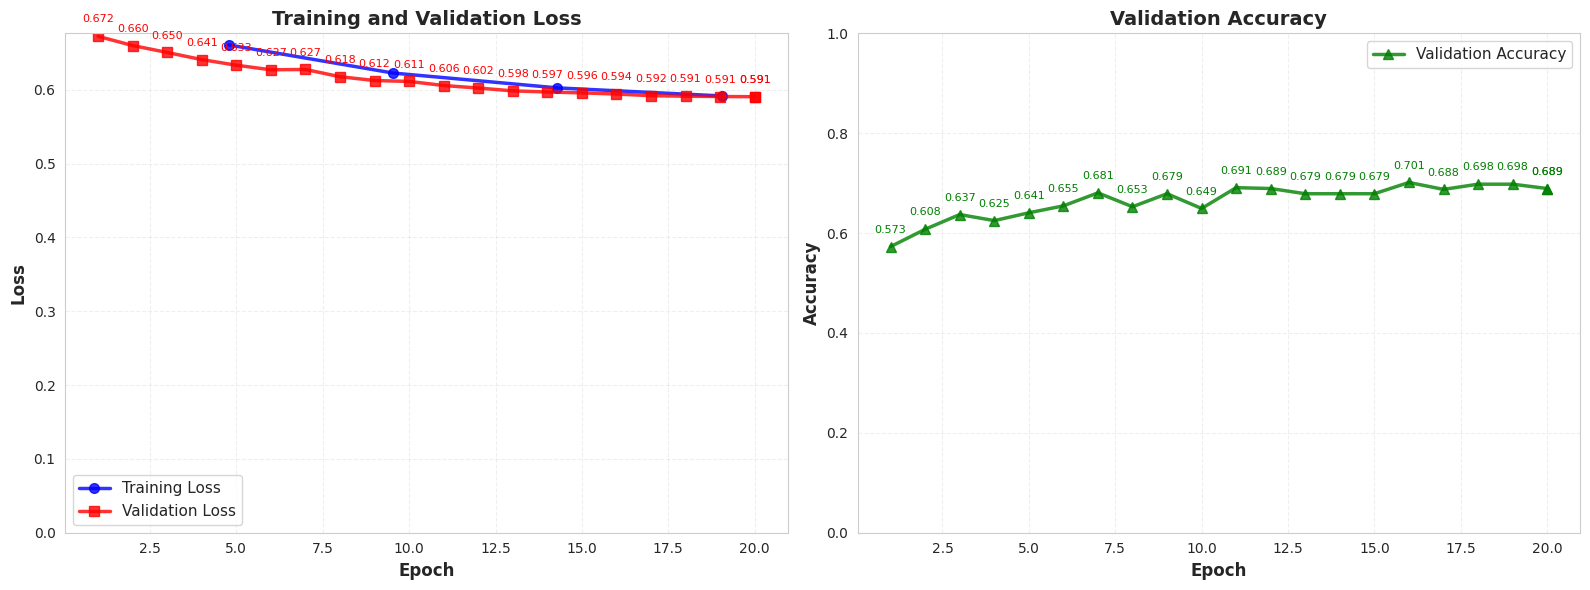


Training History Summary:
  Final Validation Accuracy: 0.6892
  Best Validation Accuracy: 0.7014 (Epoch 16.0)
  Final Validation Loss: 0.5906
  Best Validation Loss: 0.5906 (Epoch 20.0)
  Final Training Loss: 0.5916
  Initial Training Loss: 0.6607


In [12]:
# Model Training
print("=" * 60)
print("Starting Model Training")
print("=" * 60)

# Get train/validation data
train_split_texts = [train_texts[i] for i in train_indices]
train_split_labels = [train_labels[i] for i in train_indices]
val_split_texts = [train_texts[i] for i in val_indices]
val_split_labels = [train_labels[i] for i in val_indices]

print(f"Training samples: {len(train_split_texts)}")
print(f"Validation samples: {len(val_split_texts)}")

# Create datasets
train_dataset = Dataset.from_dict({
    'text': train_split_texts,
    'labels': train_split_labels
})
val_dataset = Dataset.from_dict({
    'text': val_split_texts,
    'labels': val_split_labels
})

# Tokenize
print("\nTokenizing data...")
train_dataset = train_dataset.map(
    tokenize_function, 
    batched=True,
    remove_columns=['text']  # Remove text column after tokenization to avoid confusion
)
val_dataset = val_dataset.map(
    tokenize_function, 
    batched=True,
    remove_columns=['text']  # Remove text column after tokenization to avoid confusion
)

# Load model with increased dropout
print(f"\nLoading {MODEL_NAME} with {num_labels} labels...")
from transformers import RobertaConfig

# Create config with increased dropout and label info
config = RobertaConfig.from_pretrained(MODEL_NAME)
config.hidden_dropout_prob = DROPOUT_RATE  # RoBERTa uses hidden_dropout_prob
config.attention_probs_dropout_prob = DROPOUT_RATE  # Attention dropout
config.num_labels = num_labels
config.id2label = id_to_label
config.label2id = label_to_id

model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config
)
print(f"✓ Model loaded with dropout={DROPOUT_RATE}")

# Move model to GPU if available
import torch
if torch.cuda.is_available():
    device = torch.device("cuda")
    model = model.to(device)
    print(f"✓ Model moved to GPU: {torch.cuda.get_device_name(0)}")

# Enable gradient checkpointing to reduce GPU memory and compute load
if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()
    print("✓ Gradient checkpointing enabled on model")

# Freeze bottom layers, train top 12 layers
print(f"\nFreezing bottom layers, training top {NUM_TOP_LAYERS_TO_TRAIN} layers...")
# RoBERTa-large has 24 transformer layers (0-23)
# We want to train top 12 layers (all layers) and freeze bottom 0 (none)
total_layers = len(model.roberta.encoder.layer)
layers_to_freeze = total_layers - NUM_TOP_LAYERS_TO_TRAIN  # Freeze bottom 0 (all trainable)

# Freeze embedding layer
for param in model.roberta.embeddings.parameters():
    param.requires_grad = False
print("  Frozen embeddings")

# Freeze bottom transformer layers (0 to layers_to_freeze-1)
frozen_layers = []
if layers_to_freeze > 0:
    for i in range(layers_to_freeze):
        for param in model.roberta.encoder.layer[i].parameters():
            param.requires_grad = False
        frozen_layers.append(i)
        if i < 5 or i >= layers_to_freeze - 2:  # Show first few and last few
            print(f"  Frozen layer {i}")
else:
    print("  No layers frozen (all layers trainable)")

# Train top transformer layers (layers_to_freeze to total_layers-1)
trainable_layers = []
for i in range(layers_to_freeze, total_layers):
    for param in model.roberta.encoder.layer[i].parameters():
        param.requires_grad = True
    trainable_layers.append(i)
    if i < layers_to_freeze + 3 or i >= total_layers - 2:  # Show first few and last few
        print(f"  Training layer {i}")

# Always train the classifier head
for param in model.classifier.parameters():
    param.requires_grad = True

print(f"\n✓ Training layers: {trainable_layers} + classifier head")
print(f"✓ Frozen layers: {frozen_layers} + embeddings")

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

# Training arguments with warmup and early stopping
# Memory optimization settings
use_fp16 = torch.cuda.is_available()
# Use bf16 for ROCm if available (better support than fp16)
use_bf16 = False
if torch.cuda.is_available():
    try:
        # Check if bf16 is supported
        test_tensor = torch.tensor([1.0], dtype=torch.bfloat16)
        use_bf16 = True
        use_fp16 = False
    except:
        pass

training_args = TrainingArguments(
    output_dir='./roberta-large-conspiracy-classification',
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,  # 10% warmup
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",  # Use loss for early stopping
    greater_is_better=False,  # Lower loss is better
    logging_dir='./logs',
    logging_steps=100,  # Reduced logging frequency to reduce GPU sync overhead
    report_to="none",
    seed=42,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,  # Accumulate gradients to save memory
    fp16=use_fp16,
    bf16=use_bf16,  # Use bfloat16 for ROCm if supported
    dataloader_num_workers=0,  # Reduce memory overhead from data loading
    dataloader_pin_memory=False,  # Disable pin memory to save RAM
    max_grad_norm=1.0,  # Gradient clipping to prevent exploding gradients
    save_total_limit=2,  # Keep only last 2 checkpoints to save disk space
    gradient_checkpointing=True,  # Trade compute for memory (reduces GPU load)
    dataloader_drop_last=True,  # Drop last incomplete batch to avoid GPU sync issues
    remove_unused_columns=False,  # Keep all columns to avoid re-processing
)

# Print device information
print(f"\n{'='*60}")
print("Training Configuration")
print(f"{'='*60}")
if torch.cuda.is_available():
    print(f"✓ Device: GPU ({torch.cuda.get_device_name(0)})")
    print(f"✓ Mixed Precision (FP16): {use_fp16}")
    print(f"✓ Mixed Precision (BF16): {use_bf16}")
    print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"✓ Batch size per device: {BATCH_SIZE}")
    print(f"✓ Gradient accumulation steps: {GRADIENT_ACCUMULATION_STEPS}")
    print(f"✓ Effective batch size: {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
else:
    print(f"✓ Device: CPU")
    print(f"✓ Mixed Precision (FP16): {use_fp16}")
    print(f"✓ Batch size: {BATCH_SIZE}")
    print(f"✓ Gradient accumulation steps: {GRADIENT_ACCUMULATION_STEPS}")
    print(f"✓ Effective batch size: {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
    print(f"✓ Batch size per device: {BATCH_SIZE}")
print(f"{'='*60}\n")

# Create data collator for dynamic padding
# This will pad sequences per batch to the longest sequence in that batch
# This preserves context by not truncating shorter sequences unnecessarily
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,  # Enable padding
    max_length=None,  # No max length - pad to longest in batch (up to model max)
    pad_to_multiple_of=None  # Optional: pad to multiple of 8 for efficiency
)

print("✓ Data collator created for dynamic padding")
print("  - Sequences will be padded per batch to preserve context")
print("  - Shorter sequences won't be unnecessarily padded to MAX_LENGTH")

# Create trainer with early stopping callback
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=10,  # Stop if no improvement for 2 epochs
    early_stopping_threshold=0.0001  # Minimum change to qualify as improvement
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,  # Use dynamic padding collator
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]  # Add early stopping callback
)

# Train
print(f"\nTraining model for {NUM_EPOCHS} epochs...")
try:
    # Clear GPU cache before training to prevent overload
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()  # Ensure all operations complete
        print("✓ GPU cache cleared and synchronized")

    train_result = trainer.train()
    
    # Evaluate on validation set
    print("\nEvaluating on validation set...")
    eval_result = trainer.evaluate()
    
    print(f"\n{'='*60}")
    print("Training Complete!")
    print(f"{'='*60}")
    print(f"\nTraining Loss: {train_result.training_loss:.4f}")
    print(f"\nValidation Set Performance:")
    print(f"  Accuracy: {eval_result.get('eval_accuracy', 0):.4f}")
    print(f"  F1 (macro): {eval_result.get('eval_f1_macro', 0):.4f}")
    print(f"  F1 (weighted): {eval_result.get('eval_f1_weighted', 0):.4f}")
    
    # Plot training history
    print("\n" + "=" * 60)
    print("Plotting Training History")
    print("=" * 60)
    
    # Extract training history from trainer state
    history = trainer.state.log_history
    
    # Separate training and evaluation metrics
    # Group training losses by epoch for better visualization
    train_losses_by_epoch = {}  # epoch -> list of losses
    eval_losses = []
    eval_accuracies = []
    epochs = []
    
    for log in history:
        if 'loss' in log and 'eval_loss' not in log and 'epoch' in log:
            # Training step with epoch info
            epoch = log['epoch']
            if epoch not in train_losses_by_epoch:
                train_losses_by_epoch[epoch] = []
            train_losses_by_epoch[epoch].append(log['loss'])
        elif 'eval_loss' in log and 'epoch' in log:
            # Evaluation step
            epoch = log['epoch']
            epochs.append(epoch)
            eval_losses.append(log['eval_loss'])
            if 'eval_accuracy' in log:
                eval_accuracies.append(log['eval_accuracy'])
    
    # Calculate average training loss per epoch
    train_epochs = sorted(train_losses_by_epoch.keys())
    avg_train_losses = [np.mean(train_losses_by_epoch[ep]) for ep in train_epochs]
    
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Loss (Training and Validation) - both on same plot
    if len(train_epochs) > 0 and len(avg_train_losses) > 0:
        ax1.plot(train_epochs, avg_train_losses, 'b-', label='Training Loss', linewidth=2.5, marker='o', markersize=7, alpha=0.8)
    
    if len(epochs) > 0 and len(eval_losses) > 0:
        ax1.plot(epochs, eval_losses, 'r-', label='Validation Loss', linewidth=2.5, marker='s', markersize=7, alpha=0.8)
    
    ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11, loc='best')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_ylim(bottom=0)
    # Add value annotations for validation loss
    if len(epochs) > 0 and len(eval_losses) > 0:
        for epoch, loss in zip(epochs, eval_losses):
            ax1.annotate(f'{loss:.3f}', (epoch, loss), textcoords="offset points", 
                        xytext=(0,10), ha='center', fontsize=8, color='red')
    
    # Plot 2: Accuracy
    if len(epochs) > 0 and len(eval_accuracies) > 0:
        ax2.plot(epochs, eval_accuracies, 'g-', label='Validation Accuracy', linewidth=2.5, marker='^', markersize=7, alpha=0.8)
        ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
        ax2.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11, loc='best')
        ax2.grid(True, alpha=0.3, linestyle='--')
        ax2.set_ylim([0, 1])
        # Add value annotations
        for epoch, acc in zip(epochs, eval_accuracies):
            ax2.annotate(f'{acc:.3f}', (epoch, acc), textcoords="offset points", 
                        xytext=(0,10), ha='center', fontsize=8, color='green')
    
    plt.tight_layout()
    
    # Save figure
    figures_dir = BASE / 'figures'
    figures_dir.mkdir(exist_ok=True)
    plt.savefig(figures_dir / 'training_history_roberta_large.png', dpi=150, bbox_inches='tight')
    print(f"✓ Saved training history plot to figures/training_history_roberta_large.png")
    
    plt.show()
    
    # Print summary statistics
    if len(eval_accuracies) > 0:
        print(f"\nTraining History Summary:")
        print(f"  Final Validation Accuracy: {eval_accuracies[-1]:.4f}")
        best_acc_idx = eval_accuracies.index(max(eval_accuracies))
        print(f"  Best Validation Accuracy: {max(eval_accuracies):.4f} (Epoch {epochs[best_acc_idx]:.1f})")
        if len(eval_losses) > 0:
            print(f"  Final Validation Loss: {eval_losses[-1]:.4f}")
            best_loss_idx = eval_losses.index(min(eval_losses))
            print(f"  Best Validation Loss: {min(eval_losses):.4f} (Epoch {epochs[best_loss_idx]:.1f})")
        if len(avg_train_losses) > 0:
            print(f"  Final Training Loss: {avg_train_losses[-1]:.4f}")
            print(f"  Initial Training Loss: {avg_train_losses[0]:.4f}")
    
except Exception as e:
    print(f"❌ Training failed: {e}")
    import traceback
    traceback.print_exc()
    raise


## Final Evaluation on Dev Set

Evaluate the best model on the **dev set**: text from `dev_rehydrated.jsonl`, labels from `dev_public.jsonl` (merge on `_id`, yes/no only).


In [13]:
# Load dev set: text from dev_rehydrated.jsonl, labels from dev_public.jsonl
import json
DATA = BASE / 'data'
dev_rehydrated_path = DATA / 'dev_rehydrated.jsonl'
dev_public_path = DATA / 'dev_public.jsonl'

id_to_text = {}
with open(dev_rehydrated_path, 'r') as f:
    for line in f:
        item = json.loads(line)
        id_to_text[item['_id']] = item.get('text', '')

dev_data = []
with open(dev_public_path, 'r') as f:
    for line in f:
        item = json.loads(line)
        _id = item.get('_id')
        label = item.get('conspiracy', '')
        if _id is None or label not in ('yes', 'no', 'Yes', 'No'):
            continue
        label = label.lower()
        text = id_to_text.get(_id, '')
        dev_data.append({'text': text, 'conspiracy': label})

dev_df = pd.DataFrame(dev_data)
dev_texts = dev_df['text'].tolist()
dev_labels = label_encoder.transform(dev_df['conspiracy']).tolist()
print(f"Loaded dev set: {len(dev_df)} samples (yes/no only) from dev_rehydrated + dev_public")

dev_dataset = Dataset.from_dict({'text': dev_texts, 'labels': dev_labels})
dev_dataset = dev_dataset.map(tokenize_function, batched=True)

# Load the best model from training (only from RoBERTa output_dir)
import glob
checkpoint_dirs = glob.glob('./roberta-large-conspiracy-classification/checkpoint-*')
if checkpoint_dirs:
    latest_checkpoint = max(checkpoint_dirs, key=lambda x: int(x.split('-')[-1]) if x.split('-')[-1].isdigit() else 0)
    best_model = RobertaForSequenceClassification.from_pretrained(latest_checkpoint)
    print(f"✓ Loaded model from {latest_checkpoint}")
else:
    print("No RoBERTa checkpoint found, using current model from this session")
    best_model = model

dev_data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    max_length=None,
    pad_to_multiple_of=None
)

dev_trainer = Trainer(
    model=best_model,
    tokenizer=tokenizer,
    data_collator=dev_data_collator,
    compute_metrics=compute_metrics
)

print("\n" + "=" * 60)
print("Evaluating on Dev Set (dev_rehydrated + dev_public)")
print("=" * 60)
try:
    test_results = dev_trainer.evaluate(dev_dataset)
    print("\n=== Dev Set Performance ===")
    print("=" * 60)
    for key, value in test_results.items():
        if 'loss' not in key:
            print(f"  {key}: {value:.4f}")
    print("=" * 60)
except Exception as e:
    print(f"❌ Evaluation failed: {e}")
    import traceback
    traceback.print_exc()
    raise


Loaded dev set: 77 samples (yes/no only) from dev_rehydrated + dev_public


Map: 100%|██████████| 77/77 [00:00<00:00, 3835.05 examples/s]

✓ Loaded model from ./roberta-large-conspiracy-classification/checkpoint-420



Evaluating on Dev Set (dev_rehydrated + dev_public)



=== Dev Set Performance ===
  eval_accuracy: 0.7013
  eval_f1_macro: 0.6290
  eval_f1_weighted: 0.6779
  eval_runtime: 2.2570
  eval_samples_per_second: 34.1150
  eval_steps_per_second: 0.8860


In [14]:
# Get predictions on dev set
print("\nGenerating predictions on dev set...")
predictions = dev_trainer.predict(dev_dataset)
predicted_classes = np.argmax(predictions.predictions, axis=-1)
true_labels = dev_dataset['labels']

# Convert to label names
y_true_labels = [id_to_label[label] for label in true_labels]
y_pred_labels = [id_to_label[label] for label in predicted_classes]

print("\n=== Dev Set Predictions ===")
print(f"\nTrue label distribution:")
print(pd.Series(y_true_labels).value_counts().to_dict())

print(f"\nPredicted label distribution:")
print(pd.Series(y_pred_labels).value_counts().to_dict())

# Calculate metrics
test_accuracy = accuracy_score(true_labels, predicted_classes)
test_f1_macro = f1_score(true_labels, predicted_classes, average='macro')
test_f1_weighted = f1_score(true_labels, predicted_classes, average='weighted')

print(f"\n=== Dev Set Performance (Detailed) ===")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"F1 (macro): {test_f1_macro:.4f}")
print(f"F1 (weighted): {test_f1_weighted:.4f}")

# Detailed classification report
print(f"\n=== Detailed Classification Report (Dev Set) ===")
print(classification_report(y_true_labels, y_pred_labels, target_names=label_encoder.classes_))



Generating predictions on dev set...

=== Dev Set Predictions ===

True label distribution:
{'no': 50, 'yes': 27}

Predicted label distribution:
{'no': 61, 'yes': 16}

=== Dev Set Performance (Detailed) ===
Accuracy: 0.7013
F1 (macro): 0.6290
F1 (weighted): 0.6779

=== Detailed Classification Report (Dev Set) ===
              precision    recall  f1-score   support

          no       0.72      0.88      0.79        50
         yes       0.62      0.37      0.47        27

    accuracy                           0.70        77
   macro avg       0.67      0.63      0.63        77
weighted avg       0.69      0.70      0.68        77




=== Confusion Matrix (Dev Set) ===
Rows = True labels, Columns = Predicted labels
Label order: ['no', 'yes']
[[44  6]
 [17 10]]


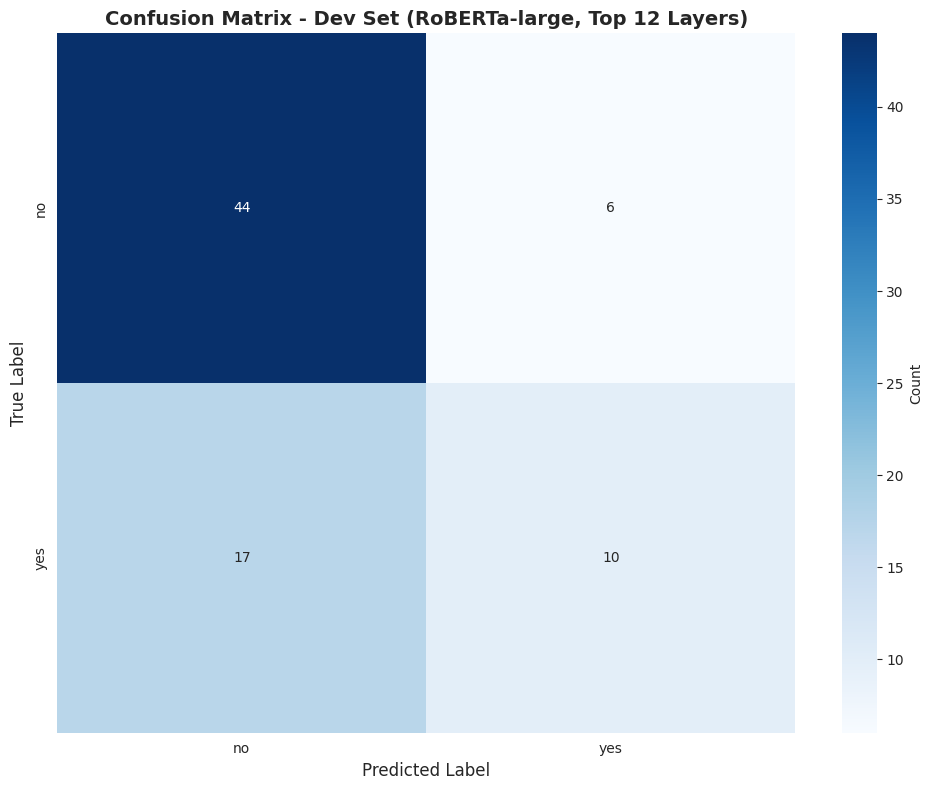


✓ Saved confusion matrix to figures/dev_confusion_matrix_roberta_bt1.png


In [15]:
# Confusion matrix for dev set
cm = confusion_matrix(true_labels, predicted_classes)
print(f"\n=== Confusion Matrix (Dev Set) ===")
print("Rows = True labels, Columns = Predicted labels")
print(f"Label order: {list(label_encoder.classes_)}")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Dev Set (RoBERTa-large, Top 12 Layers)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()

# Save figure
figures_dir = BASE / 'figures'
figures_dir.mkdir(exist_ok=True)
plt.savefig(figures_dir / 'dev_confusion_matrix_roberta_bt1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved confusion matrix to figures/dev_confusion_matrix_roberta_bt1.png")


## Sample Dev Set Predictions


In [16]:
# Compare predictions with true labels for some examples
print("\n=== Sample Dev Set Predictions ===")
sample_indices = np.random.choice(len(dev_df), size=min(10, len(dev_df)), replace=False)

results_df = pd.DataFrame({
    'true_label': [y_true_labels[i] for i in sample_indices],
    'predicted_label': [y_pred_labels[i] for i in sample_indices],
    'text_preview': [dev_df.iloc[i]['text'][:100] + '...' for i in sample_indices],
    'correct': [y_true_labels[i] == y_pred_labels[i] for i in sample_indices]
})

print(results_df.to_string(index=False))

print(f"\n✓ Dev set evaluation complete!")
print(f"  Total dev samples: {len(dev_df)}")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  F1 (macro): {test_f1_macro:.4f}")
print(f"  F1 (weighted): {test_f1_weighted:.4f}")
print(f"  Correct predictions: {(np.array(y_true_labels) == np.array(y_pred_labels)).sum()}/{len(y_true_labels)}")



=== Sample Dev Set Predictions ===
true_label predicted_label                                                                                             text_preview  correct
        no              no  We don't have enough places to sit. We need more chairs? No...now it's the time of the couch, here i...     True
        no              no  Small ape trying to do my part. I’m a plumber and I’ve been collecting various metals  for some time...     True
        no              no  This man took DMT and had, what he claims, an entity possess him. He spent a lot of money after this...     True
       yes             yes  RFK Jr. claims that CIA operatives destroyed evidence in his father’s assassination that clearly imp...     True
        no              no  The Philadelphi Corridor — or to put it more correctly, the southern closing point [of Gaza] — must ...     True
        no             yes  I found this article on Bret & Heather interesting and thought it would be an interesting 

## Summary

This deep learning approach:
- **Binary classification**: Only yes/no labels; *cant_tell* samples are excluded from training, validation, and testing
- **Uses only text and labels**: No engineered features needed - the transformer model learns representations directly from text
- **Model**: RoBERTa-large (24 layers, training top 12 layers) for better performance
- **Evaluation Strategy**:
  - **Train/Validation Split**: 90% training, 10% validation (stratified split on full training data)
  - **Final Evaluation**: Dev set (dev_rehydrated + dev_public, yes/no only)
  - **Metrics**: Accuracy, F1-macro, F1-weighted reported for validation and dev set
  - **Training**: 5 epochs with early stopping based on validation performance
- **Advantages**: 
  - Can capture complex semantic patterns in text
  - No feature engineering required
  - Transfer learning from pre-trained language model
  - Robust evaluation through k-fold CV
- **Comparison with feature-based models**: Deep learning models often perform better on text classification tasks, especially when there's sufficient training data

**Note**: For production use, you might want to:
- Experiment with different transformer models (BERT, RoBERTa, etc.)
- Tune hyperparameters (learning rate, batch size, epochs)
- Use ensemble predictions from all k-fold models
- Apply class weighting if there's class imbalance
